In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style = "whitegrid")
print("Imports successful!")

Imports successful!


In [4]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud rate: {df['Class'].mean() * 100:.3f}%")

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


In [5]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["Time"])

scaler = StandardScaler()
df_clean["Amount"] = scaler.fit_transform(df_clean[["Amount"]])
print("Amount column before scaling:")
print(f"  Mean: {df['Amount'].mean():.2f},  Std: {df['Amount'].std():.2f}")
print("\nAmount column after scaling:")
print(f"  Mean: {df_clean['Amount'].mean():.4f},  Std: {df_clean['Amount'].std():.4f}")

Amount column before scaling:
  Mean: 88.35,  Std: 250.12

Amount column after scaling:
  Mean: -0.0000,  Std: 1.0000


In [6]:
X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print(f"Features (X) shape: {X.shape}")
print(f"Labels   (y) shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features (X) shape: (284807, 29)
Labels   (y) shape: (284807,)
Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} transactions")
print(f"Test set:       {X_test.shape[0]:,} transactions")
print(f"\nFraud in training set: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test set:     {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Training set:   227,845 transactions
Test set:       56,962 transactions

Fraud in training set: 394 (0.173%)
Fraud in test set:     98 (0.172%)


In [8]:
print("Before SMOTE:")
print(f"  Legitimate: {(y_train == 0).sum():,}")
print(f"  Fraud:      {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_balanced == 0).sum():,}")
print(f"  Fraud:      {(y_train_balanced == 1).sum():,}")
print(f"\nTraining set is now perfectly balanced!")

Before SMOTE:
  Legitimate: 227,451
  Fraud:      394

After SMOTE:
  Legitimate: 227,451
  Fraud:      227,451

Training set is now perfectly balanced!


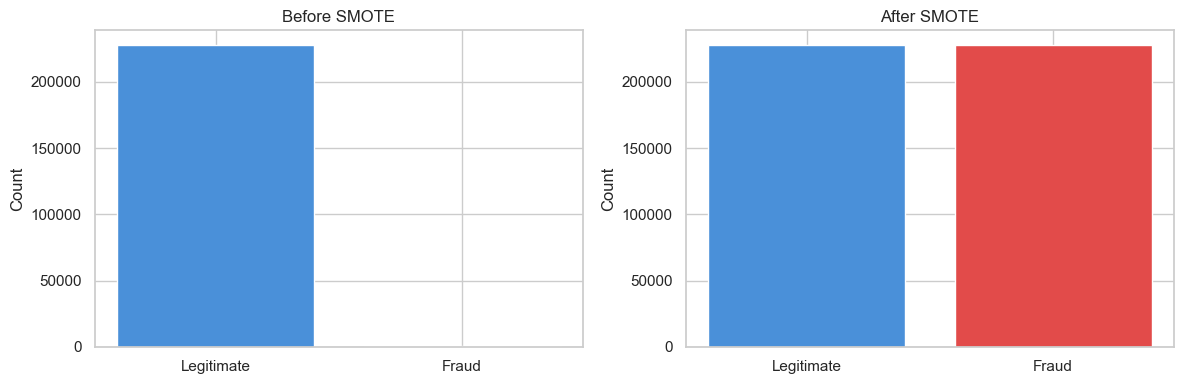

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].bar(["Legitimate", "Fraud"],
            [(y_train == 0).sum(), (y_train == 1).sum()],
            color=["#4A90D9", "#E24B4A"])
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Count")

# After
axes[1].bar(["Legitimate", "Fraud"],
            [(y_train_balanced == 0).sum(), (y_train_balanced == 1).sum()],
            color=["#4A90D9", "#E24B4A"])
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/smote_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Save as CSV files
X_train_balanced.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)

pd.Series(y_train_balanced, name="Class").to_csv(
    "../data/processed/y_train.csv", index=False)
pd.Series(y_test, name="Class").to_csv(
    "../data/processed/y_test.csv", index=False)

print("Saved processed data to data/processed/:")
print(f"  X_train.csv  — {X_train_balanced.shape}")
print(f"  X_test.csv   — {X_test.shape}")
print(f"  y_train.csv  — {y_train_balanced.shape}")
print(f"  y_test.csv   — {y_test.shape}")

Saved processed data to data/processed/:
  X_train.csv  — (454902, 29)
  X_test.csv   — (56962, 29)
  y_train.csv  — (454902,)
  y_test.csv   — (56962,)
